In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

In [3]:
image = data.camera()
image = resize(image, (256, 256))

In [4]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])


In [5]:
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    cy, cx = ph // 2, pw // 2

    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    return fft2(ifftshift(padded))

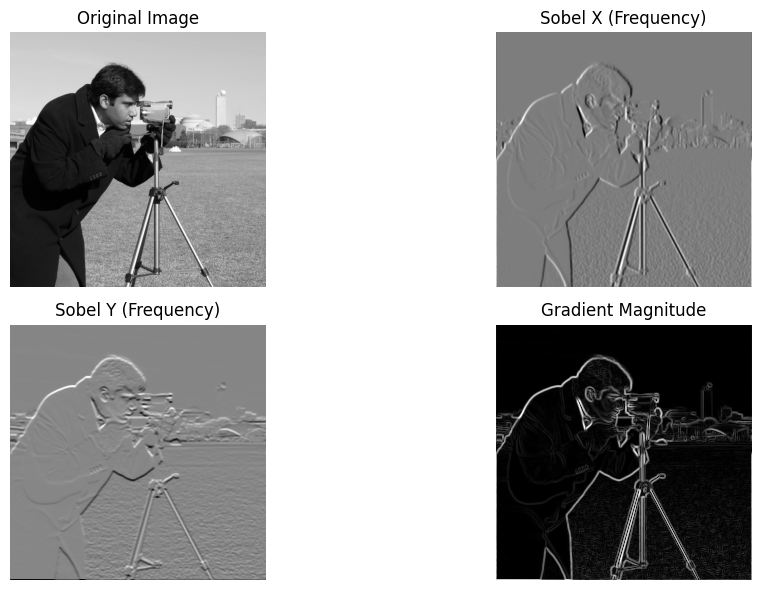

In [6]:
# FFT of image
F = fft2(image)

# FFT of Sobel filters
Hx = center_embed_kernel(sobel_x, image.shape)
Hy = center_embed_kernel(sobel_y, image.shape)

# Apply filters in frequency domain
Gx = F * Hx
Gy = F * Hy

# Inverse FFT
gx = ifft2(Gx).real
gy = ifft2(Gy).real

# Gradient magnitude
gradient = np.sqrt(gx**2 + gy**2)

# Plot results
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gx, cmap='gray')
plt.title('Sobel X (Frequency)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gy, cmap='gray')
plt.title('Sobel Y (Frequency)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gradient, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()